<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook8_MCTS_Educational.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 8 — Monte Carlo Tree Search (Educational)

This notebook demonstrates the core ideas behind Monte Carlo Tree Search (MCTS).

Topics:
- Search tree
- Selection (UCT)
- Expansion
- Simulation (rollout)
- Backpropagation
- Tree statistics
- UCT vs random policy

This is an educational implementation intended to explain the algorithm.


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(10)
np.random.seed(10)


In [2]:
class GridWorld:
    ACTIONS=["U","D","L","R"]
    def __init__(self,size=5):
        self.size=size
        self.goal=(4,4)
        self.reset()
    def clone(self):
        g=GridWorld(self.size)
        g.goal=self.goal
        g.state=self.state
        return g
    def reset(self):
        self.state=(0,0)
        return self.state
    def step(self,a):
        x,y=self.state
        if a==0:x=max(0,x-1)
        elif a==1:x=min(self.size-1,x+1)
        elif a==2:y=max(0,y-1)
        elif a==3:y=min(self.size-1,y+1)
        self.state=(x,y)
        r=-1
        done=False
        if self.state==self.goal:
            r=20
            done=True
        return self.state,r,done


## MCTS Node

In [3]:
class Node:
    def __init__(self,state,parent=None,action=None):
        self.state=state
        self.parent=parent
        self.action=action
        self.children={}
        self.visits=0
        self.value=0.0

    def uct(self,c=1.41):
        if self.visits==0:
            return float("inf")
        return self.value/self.visits + c*math.sqrt(math.log(self.parent.visits)/self.visits)


## MCTS

In [4]:
class MCTS:
    def __init__(self,env,rollout_depth=8):
        self.env=env
        self.rollout_depth=rollout_depth

    def rollout(self,world):
        total=0
        gamma=0.95
        for t in range(self.rollout_depth):
            _,r,d=world.step(random.randint(0,3))
            total+=(gamma**t)*r
            if d:
                break
        return total

    def search(self,iterations=200):
        root=Node(self.env.state)

        for _ in range(iterations):

            node=root
            world=self.env.clone()

            while node.children:
                node=max(node.children.values(),key=lambda n:n.uct())
                world.step(node.action)

            if node.visits>0:
                for a in range(4):
                    w=world.clone()
                    s,r,d=w.step(a)
                    node.children[a]=Node(s,node,a)

                node=random.choice(list(node.children.values()))
                world.step(node.action)

            reward=self.rollout(world)

            while node is not None:
                node.visits+=1
                node.value+=reward
                node=node.parent

        return root


## Run Search

In [5]:
env=GridWorld()
env.reset()

mcts=MCTS(env)

root=mcts.search(300)

for a,n in root.children.items():
    print(GridWorld.ACTIONS[a],
          "Visits:",n.visits,
          "Mean Value:",round(n.value/max(n.visits,1),2))


U Visits: 39 Mean Value: -6.73
D Visits: 52 Mean Value: -6.39
L Visits: 170 Mean Value: -6.45
R Visits: 38 Mean Value: -6.73


## Best Action

In [6]:
best=max(root.children.values(),key=lambda n:n.visits)
print("Recommended:",GridWorld.ACTIONS[best.action])


Recommended: L


## Visit Distribution

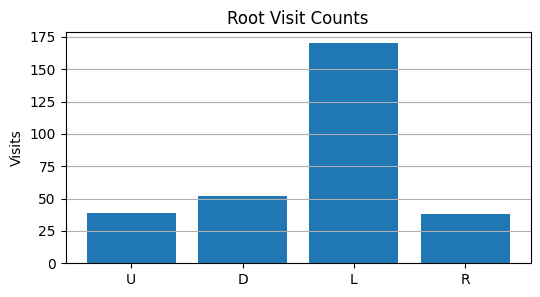

In [7]:
acts=[]
vis=[]

for a,n in root.children.items():
    acts.append(GridWorld.ACTIONS[a])
    vis.append(n.visits)

plt.figure(figsize=(6,3))
plt.bar(acts,vis)
plt.title("Root Visit Counts")
plt.ylabel("Visits")
plt.grid(axis="y")
plt.show()


## Value Estimates

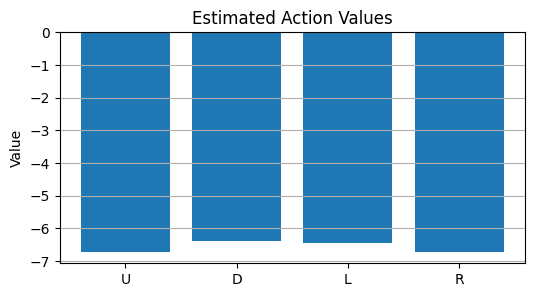

In [8]:
vals=[n.value/max(n.visits,1) for n in root.children.values()]

plt.figure(figsize=(6,3))
plt.bar(acts,vals)
plt.title("Estimated Action Values")
plt.ylabel("Value")
plt.grid(axis="y")
plt.show()


# Discussion

MCTS consists of four phases:

1. Selection using UCT
2. Expansion
3. Simulation (rollout)
4. Backpropagation

Modern planners such as AlphaGo, AlphaZero, MuZero, and educational
MC-AIXI approximations all use variants of Monte Carlo Tree Search.

## Next Notebook

Notebook 9 will introduce:

- Universal program enumeration (toy)
- Enumerable hypothesis spaces
- Prefix-free coding intuition
- Universal priors over programs
- Bringing the agent closer to a Universal AI architecture.
